# AA-UTE 2026
## P2 - Estacionariedad y descomposición

En P1 miramos una demanda sintética, sus escalas temporales y sus componentes. En este práctico usamos la misma lógica para conectar tendencia, estacionalidad y variabilidad con la idea de estacionariedad.

Dataset: series sintéticas autocontenidas con convención `unique_id`, `ds`, `y`.

Este práctico es una versión reducida y guiada de ideas usadas en *Forecasting: Principles and Practice*, versión Python: https://otexts.com/fpppy/. 


### Trabajo a realizar

A lo largo del notebook encontrarán las siguientes palabras claves:

* **\# COMPLETAR**  -> indica que se requiere completar el código. 
  
  
* **\# EXPERIMENTAR** -> indica que la celda contiene código funcional que permite experimentar variando parámetros de las funciones. Es posible, si lo requiere la experimentación, duplicar la celda y realizar los cambio que sean de interés en el código.
  
  
* **\# DISCUTIR** -> se espera una discusión de los experimentos realizados y/o de las preguntas formuladas
  
  
  
* **\# RESPONDER** -> se espera una respuesta a preguntas concretas

## Objetivos e idea mínima

Al terminar deberían poder mirar una serie y responder:

- ¿Parece tener tendencia?
- ¿Parece tener estacionalidad?
- ¿La media cambia en el tiempo?
- ¿La variabilidad cambia en el tiempo?
- ¿Qué información da una descomposición?
- ¿Qué cambia cuando aplicamos diferencias?

Idea central: si el nivel, la variabilidad o la dependencia temporal cambian mucho, la serie original difícilmente se comporte como estacionaria. La descomposición ayuda a separar componentes antes de pensar en modelos.


### Uso en Google Colab

Si estás ejecutando este notebook en Google Colab y aparece un error de dependencias, ejecutá la siguiente celda de instalación. En Jupyter local o en el entorno del curso normalmente no hace falta.


In [ ]:
# En Google Colab, descomentá y ejecutá si falta alguna dependencia:
# !pip install -q numpy pandas matplotlib statsmodels


## Setup

Importamos librerías, fijamos semilla y configuramos gráficos.


In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.seasonal import STL, seasonal_decompose
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings("ignore", category=FutureWarning)

SEED = 42
rng = np.random.default_rng(SEED)
np.random.seed(SEED)

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


## Funciones auxiliares

Definimos funciones auxiliares para generar series, graficar y repetir el mismo diagnóstico en varios casos.


In [2]:
def generar_series_estacionariedad(seed=42, periods=24 * 60, start="2026-01-01"):
    """Genera tres series horarias sintéticas con columnas unique_id, ds, y."""
    rng_local = np.random.default_rng(seed)
    ds = pd.date_range(start=start, periods=periods, freq="h")
    step = np.arange(periods)
    hour = ds.hour.to_numpy()
    dayofweek = ds.dayofweek.to_numpy()

    ruido_estable = rng_local.normal(0, 25, periods)
    estacionaria = 1000 + ruido_estable

    tendencia = 900 + 0.12 * step + rng_local.normal(0, 25, periods)

    patron_diario = 120 * np.sin(2 * np.pi * (hour - 7) / 24)
    patron_semanal = np.where(dayofweek < 5, 60, -90)
    tendencia_estacional = 1100 + 0.08 * step + patron_diario + patron_semanal + rng_local.normal(0, 30, periods)

    return pd.concat(
        [
            pd.DataFrame({"unique_id": "nivel_estable", "ds": ds, "y": estacionaria}),
            pd.DataFrame({"unique_id": "con_tendencia", "ds": ds, "y": tendencia}),
            pd.DataFrame({"unique_id": "tendencia_estacional", "ds": ds, "y": tendencia_estacional}),
        ],
        ignore_index=True,
    )


def seleccionar_serie(df, unique_id):
    """Devuelve una serie pandas indexada por fecha para un unique_id."""
    return df.loc[df["unique_id"] == unique_id].set_index("ds")["y"].asfreq("h")


def plot_series_simple(series, title, ylabel="valor"):
    """Grafica una serie temporal simple."""
    plt.figure(figsize=(14, 4))
    plt.plot(series.index, series.values, linewidth=1)
    plt.title(title)
    plt.xlabel("Fecha")
    plt.ylabel(ylabel)
    plt.show()


def plot_rolling_stats(series, window, title):
    """Grafica serie, media móvil y desvío móvil."""
    rolling_mean = series.rolling(window).mean()
    rolling_std = series.rolling(window).std()

    fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
    axes[0].plot(series.index, series, alpha=0.45, label="serie")
    axes[0].plot(rolling_mean.index, rolling_mean, linewidth=2, label=f"media móvil {window}")
    axes[0].set_title(title)
    axes[0].legend()

    axes[1].plot(rolling_std.index, rolling_std, color="tab:red", label=f"desvío móvil {window}")
    axes[1].set_title("Variabilidad local")
    axes[1].legend()
    plt.tight_layout()
    plt.show()


def plot_acf_simple(series, lags, title):
    """Grafica ACF para una serie sin valores faltantes."""
    fig, ax = plt.subplots(figsize=(12, 4))
    plot_acf(series.dropna(), lags=lags, ax=ax, zero=False)
    ax.set_title(title)
    ax.set_xlabel("Lag")
    ax.set_ylabel("Autocorrelación")
    plt.tight_layout()
    plt.show()


def resumen_adf(series, nombre):
    """Devuelve un resumen mínimo de la prueba ADF."""
    statistic, p_value, used_lags, n_obs, critical_values, _ = adfuller(series.dropna(), autolag="AIC")
    return {
        "serie": nombre,
        "estadistico_adf": statistic,
        "p_value": p_value,
        "lags_usados": used_lags,
        "observaciones": n_obs,
        "valor_critico_5%": critical_values["5%"],
    }


## Parte 1 - Creación de datos

Creamos tres series chicas y controladas. Este formato (`unique_id`, `ds`, `y`) es el mismo que usan ejemplos de FPPpy/Nixtla y facilita pasar luego a modelos de forecasting.


In [3]:
df = generar_series_estacionariedad(seed=SEED)
df.head()


,unique_id,ds,y
0,nivel_estable,2026-01-01 00:00:00,1007.617927
1,nivel_estable,2026-01-01 01:00:00,974.000397
2,nivel_estable,2026-01-01 02:00:00,1018.761280
3,nivel_estable,2026-01-01 03:00:00,1023.514118
4,nivel_estable,2026-01-01 04:00:00,951.224120


In [4]:
print(df.shape)
df.groupby("unique_id").size()


(4320, 3)


unique_id
con_tendencia           1440
nivel_estable           1440
tendencia_estacional    1440
dtype: int64

### DISCUTIR

1. ¿Qué representa cada `unique_id`?
2. ¿Qué ventajas tiene generar datos sintéticos para una primera demostración?
3. ¿Qué limitaciones tiene sacar conclusiones desde datos sintéticos?

**Respuestas**


## Parte 2 - Visualización de las series

Antes de calcular tests, miramos las series. La inspección visual es parte del diagnóstico, no un adorno.


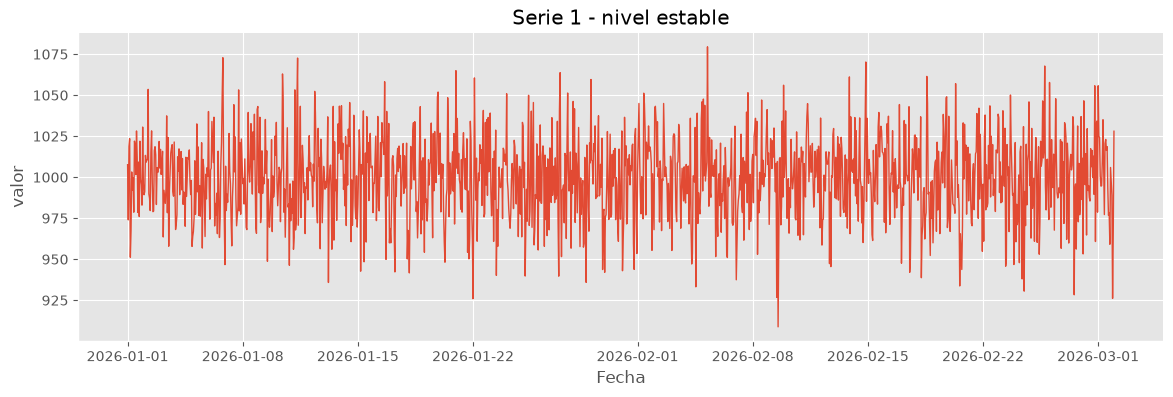

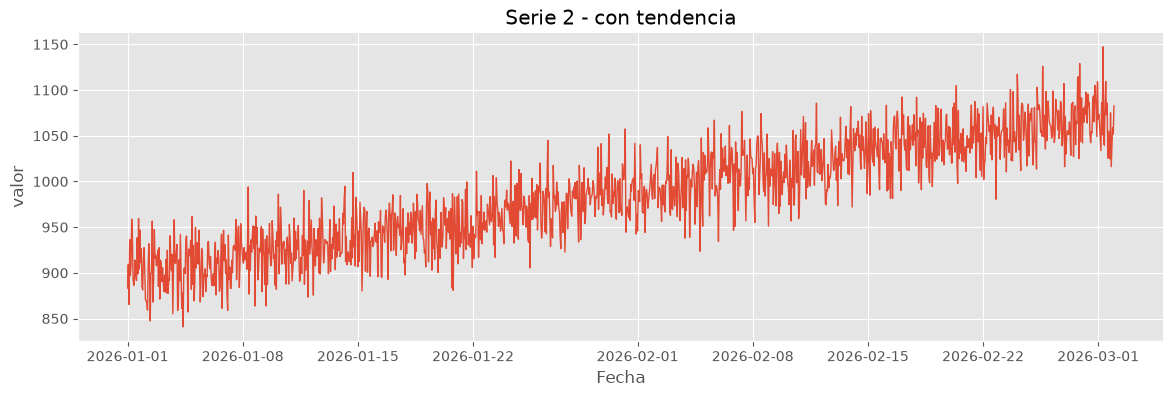

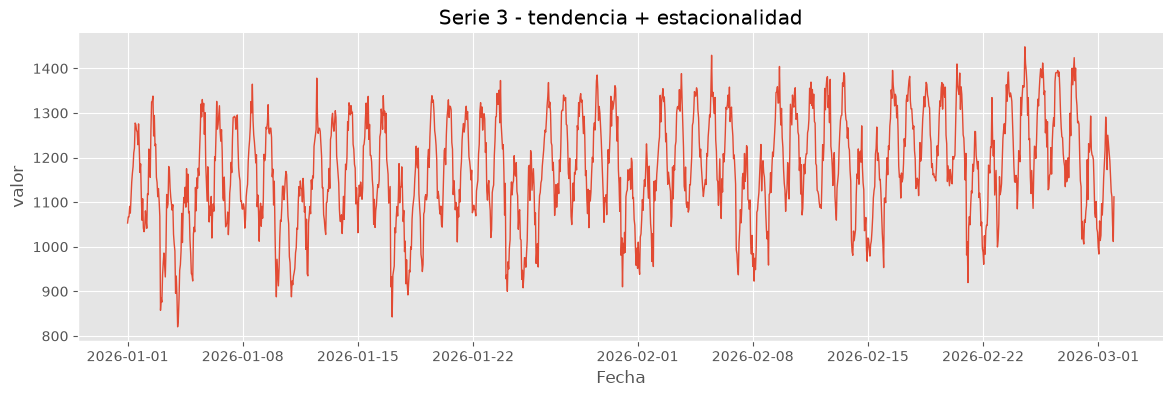

In [5]:
serie_estable = seleccionar_serie(df, "nivel_estable")
serie_tendencia = seleccionar_serie(df, "con_tendencia")
serie_estacional = seleccionar_serie(df, "tendencia_estacional")

plot_series_simple(serie_estable, "Serie 1 - nivel estable")
plot_series_simple(serie_tendencia, "Serie 2 - con tendencia")
plot_series_simple(serie_estacional, "Serie 3 - tendencia + estacionalidad")


### RESPONDER / # PREGUNTA

1. ¿Cuál parece más estacionaria?
2. ¿Cuál tiene una media que cambia en el tiempo?
3. ¿Dónde se ve más clara la estacionalidad?

**Respuestas**

1. la nivel estable
2. con tendencia
3. tendencia mas estacionalidad


## Parte 3 - Rolling windows como evidencia simple

Comparamos media móvil y desvío móvil. Si cambian mucho en el tiempo, hay evidencia visual contra estacionariedad práctica.


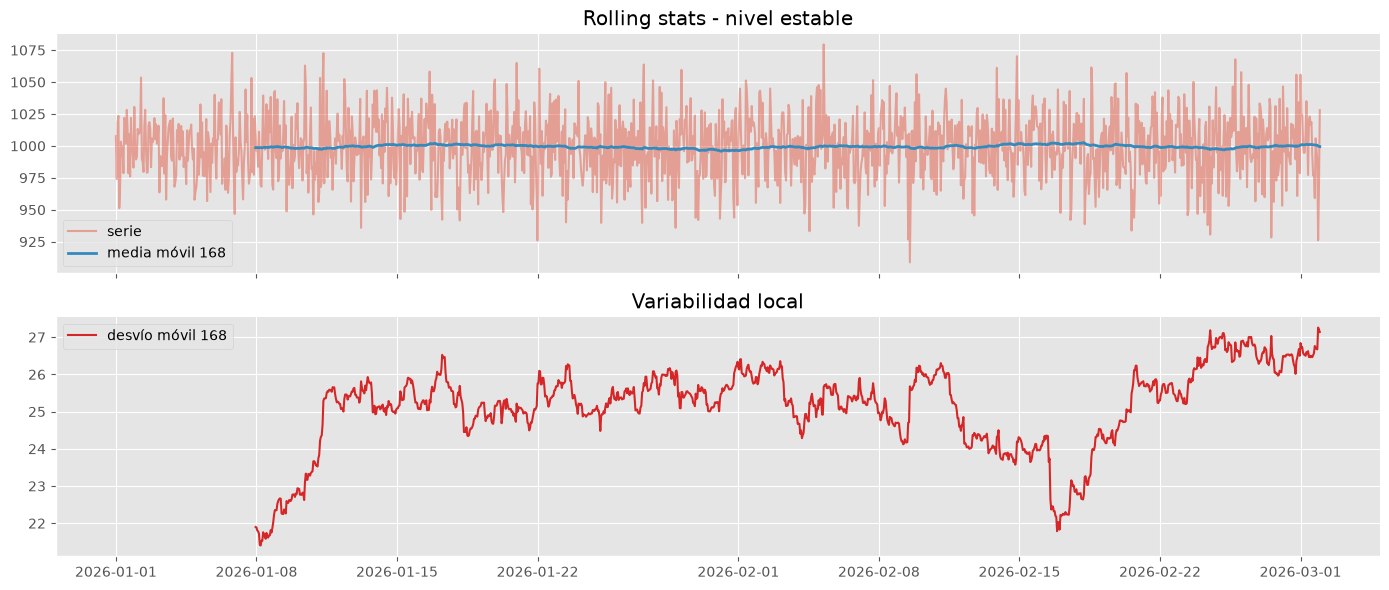

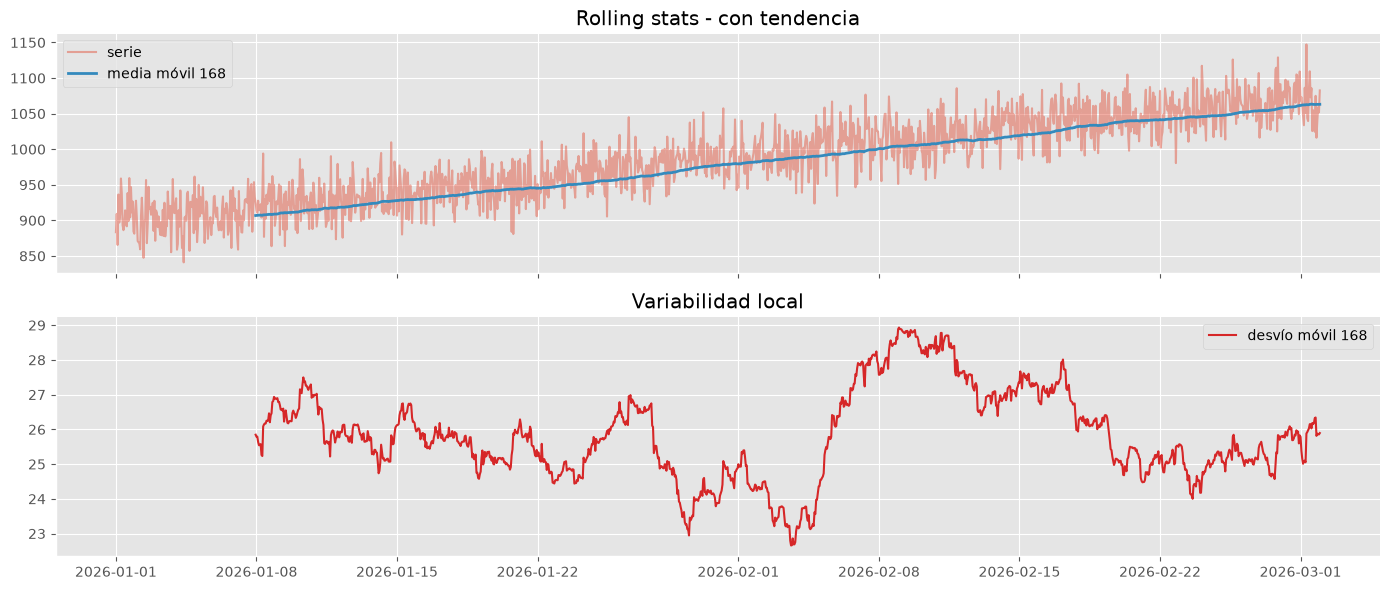

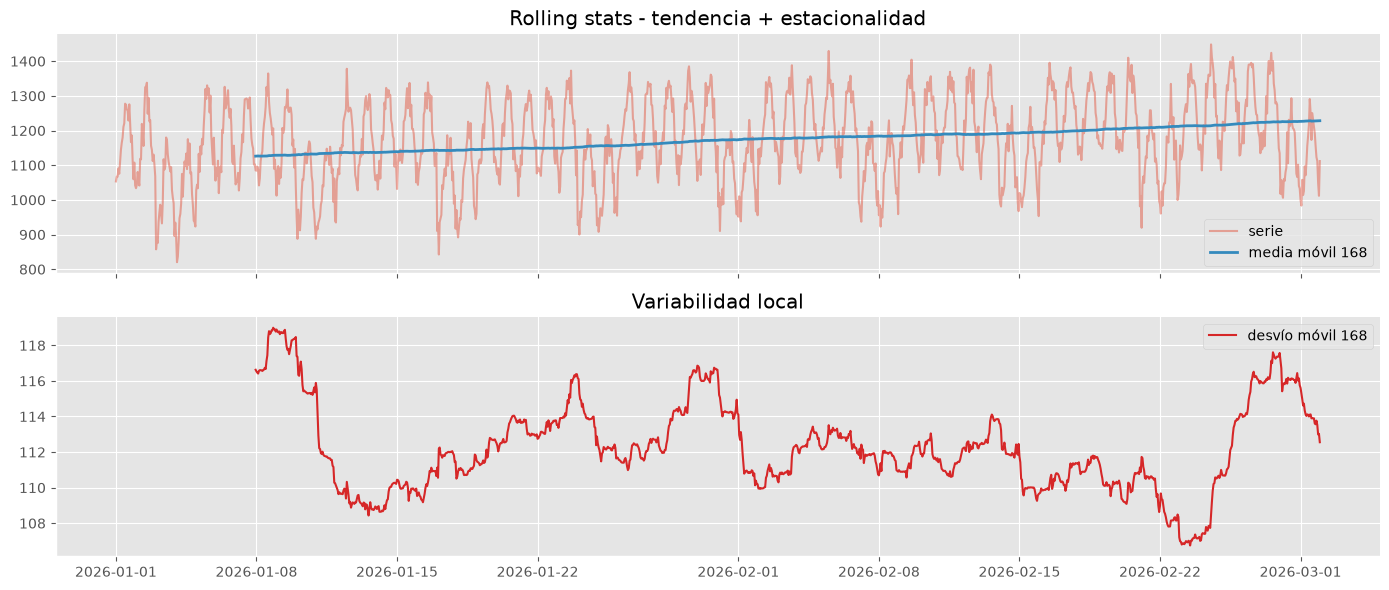

In [16]:
ventana = 24*7  # EXPERIMENTAR: probar 24, 24*7 o 24*14

plot_rolling_stats(serie_estable, ventana, "Rolling stats - nivel estable")
plot_rolling_stats(serie_tendencia, ventana, "Rolling stats - con tendencia")
plot_rolling_stats(serie_estacional, ventana, "Rolling stats - tendencia + estacionalidad")


### DISCUTIR

1. ¿Qué ventana conviene usar para suavizar el patrón intradiario?
2. ¿Qué se puede esconder si la ventana es demasiado grande?

**Respuestas**
1. la mas grande
2. patrones dentro de la ventana quedarian suavizados, ocultados en la media

## Parte 4 - ACF como herramienta exploratoria

La ACF ayuda a ver dependencia temporal. En una serie con tendencia suele caer lentamente. En una serie estacional aparecen picos cerca del período estacional.


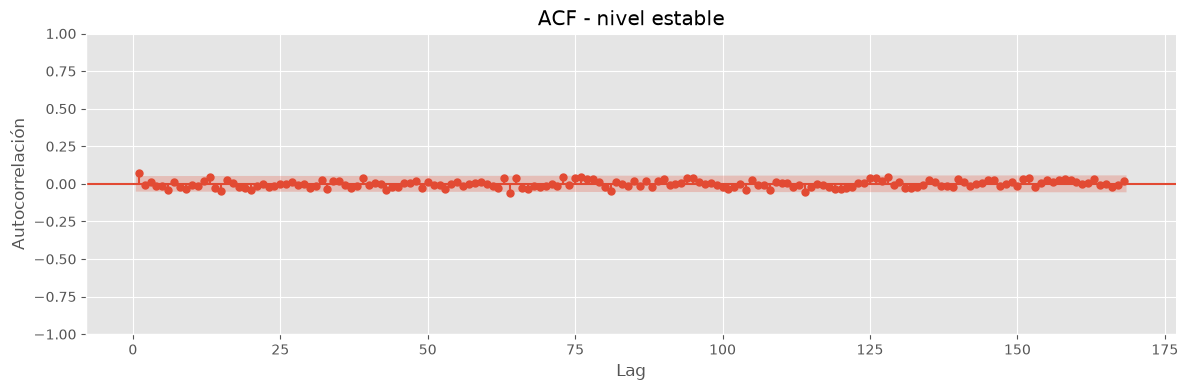

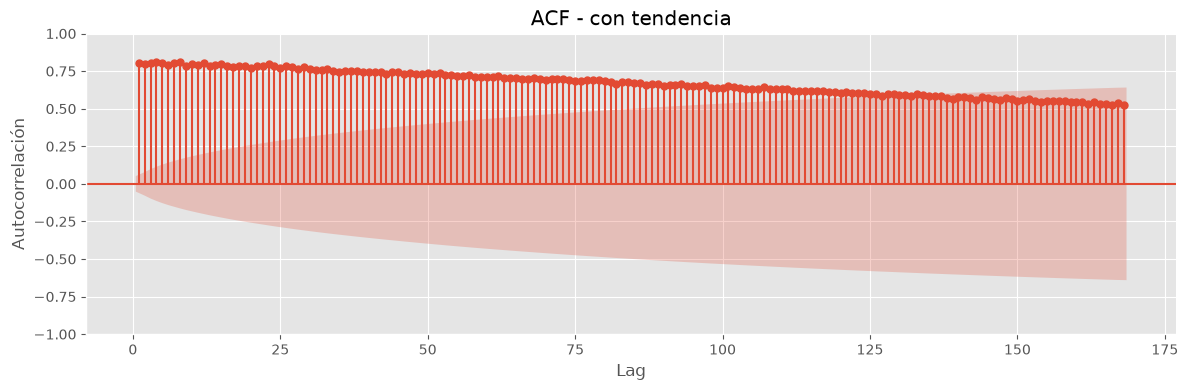

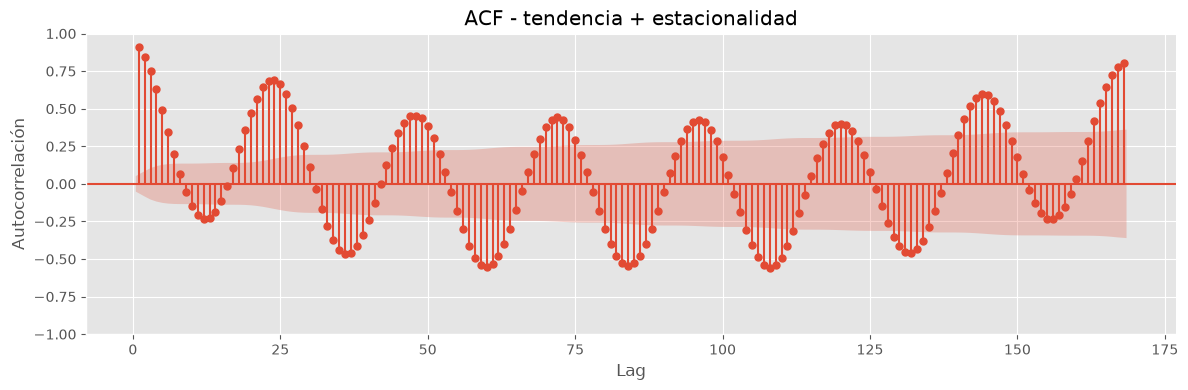

In [10]:
lags = 24 * 7  # EXPERIMENTAR: cambiar a 48 o 24*14.

plot_acf_simple(serie_estable, lags, "ACF - nivel estable")
plot_acf_simple(serie_tendencia, lags, "ACF - con tendencia")
plot_acf_simple(serie_estacional, lags, "ACF - tendencia + estacionalidad")


### RESPONDER / # PREGUNTA

1. ¿Qué esperarías ver cerca del lag 24?
2. ¿Qué esperarías ver cerca del lag 168?
3. ¿Por qué una ACF que cae lento puede sugerir tendencia?

**Respuestas**


## Parte 5 - Descomposición

Aplicamos una descomposición aditiva a la serie con tendencia y estacionalidad. En FPPpy se enfatiza que la descomposición separa tendencia-ciclo, estacionalidad y residuo. Acá lo usamos como herramienta visual y de interpretación, no como modelo final ni como pronóstico.

En STL, `period=24` y `period=24*7` responden preguntas distintas. No se trata de elegir “el mejor” período de forma universal, sino de decidir qué periodicidad queremos representar: diaria, semanal o una combinación.


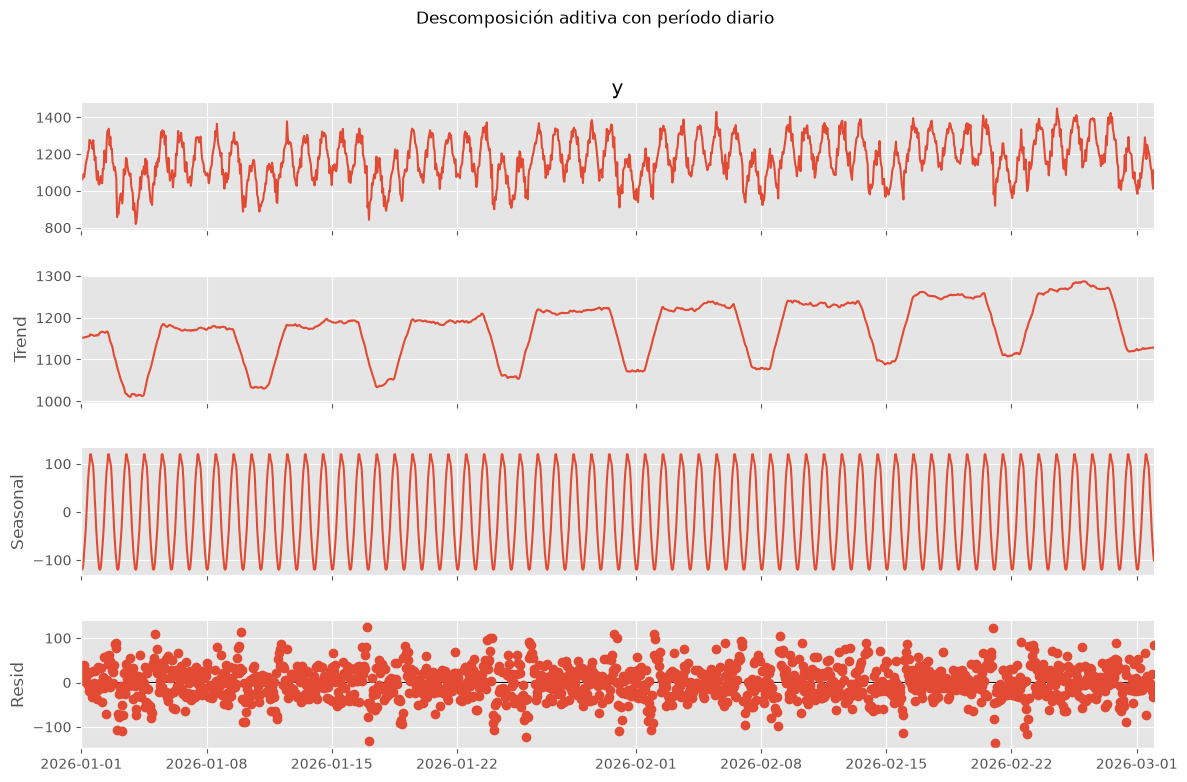

In [11]:
periodo_diario = 24

# Descomposición clásica, parecida a la usada en P1.
descomposicion_24 = seasonal_decompose(
    serie_estacional,
    model="additive",
    period=periodo_diario,
    extrapolate_trend="freq",
)

fig = descomposicion_24.plot()
fig.set_size_inches(12, 8)
fig.suptitle("Descomposición aditiva con período diario", y=1.02)
plt.show()


In [ ]:
# EXPERIMENTAR: STL es más flexible que la descomposición clásica.
# Probar period=24*7 y comparar qué periodicidad queda representada.
stl = STL(serie_estacional, period=24, robust=True).fit()

fig = stl.plot()
fig.set_size_inches(12, 8)
fig.suptitle("Descomposición STL con período diario", y=1.02)
plt.show()


### RESPONDER / # PREGUNTA

1. ¿Qué componente explica el cambio de nivel?
2. ¿Qué componente explica el patrón repetido?
3. ¿Qué pasa si elegimos mal el período estacional?

**Respuestas**


## Parte 6 - Diferencias

La diferencia regular mira cambios entre observaciones consecutivas. La diferencia estacional compara contra el mismo punto del ciclo anterior.


In [ ]:
diferencias = pd.DataFrame(index=serie_estacional.index)
diferencias["original"] = serie_estacional

# >>> COMPLETAR: primera diferencia y diferencia estacional diaria.
diferencias["diff_1"] = serie_estacional.diff()
diferencias["diff_24"] = serie_estacional.diff(24)

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
for ax, columna in zip(axes, diferencias.columns):
    ax.plot(diferencias.index, diferencias[columna], linewidth=1)
    ax.set_title(columna)
plt.tight_layout()
plt.show()


In [ ]:
plot_acf_simple(diferencias["original"], 24 * 7, "ACF - original")
plot_acf_simple(diferencias["diff_1"], 24 * 7, "ACF - diferencia regular")
plot_acf_simple(diferencias["diff_24"], 24 * 7, "ACF - diferencia estacional diaria")


### RESPONDER / # PREGUNTA

1. ¿La serie diferenciada parece más estacionaria que la original?
2. ¿Qué se gana al diferenciar?
3. ¿Qué se pierde al diferenciar?
4. ¿Qué riesgo tiene sobrediferenciar?

**Respuestas**


## Parte 7 - ADF como apoyo opcional

La prueba ADF puede aportar evidencia, pero no reemplaza mirar la serie, revisar la frecuencia, mirar la ACF ni entender el problema de dominio. La interpretamos como un elemento más del diagnóstico.

Advertencia: un `p_value` bajo en ADF no significa automáticamente que la serie no tenga estructura temporal relevante. El test evalúa una hipótesis específica de raíz unitaria; una serie con tendencia determinística, estacionalidad fuerte o componentes modelables puede requerir interpretación visual y de dominio.


In [ ]:
resultados_adf = pd.DataFrame(
    [
        resumen_adf(serie_estable, "nivel_estable"),
        resumen_adf(serie_tendencia, "con_tendencia"),
        resumen_adf(serie_estacional, "tendencia_estacional"),
        resumen_adf(diferencias["diff_1"], "diff_1"),
        resumen_adf(diferencias["diff_24"], "diff_24"),
    ]
)

resultados_adf


## Parte 8 - Ejercicios posibles

1. Repetir el análisis con una serie real (us_employment, beer, etc)
2. En la parte 4, agregar plots de autocorrelación parcial

## Para seguir leyendo

Este práctico es una versión reducida y guiada. Quien quiera ver el desarrollo más completo puede revisar:

- Forecasting: Principles and Practice, versión Python: https://otexts.com/fpppy/
- Python Time Series Handbook: https://filippomb.github.io/python-time-series-handbook/
- Statsmodels: documentación de `seasonal_decompose`, `STL`, `plot_acf`, `plot_pacf`  y `adfuller`.
